In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import welch

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
files = {
    'Healthy': {
        'path': '../data/Normal_1.mat',
        'var':  'X098_DE_time',
        'rpm':  1772,
    },
    'Inner Race': {
        'path': '../data/IR007_1.mat',
        'var':  'X106_DE_time',
        'rpm':  1772,
    },
    'Ball': {
        'path': '../data/B007_1.mat',
        'var':  'X119_DE_time',
        'rpm':  1772,
    },
    'Outer Race': {
        'path': '../data/OR007@6_1.mat',
        'var':  'X131_DE_time',
        'rpm':  1772,
    },
}

fs = 12000  # Hz, sampling frequency for drive-end channel

In [4]:
signals = {}
for condition, info in files.items():
    mat = loadmat(info['path'])
    signals[condition] = mat[info['var']].flatten()

In [5]:
def single_sided_fft(signal, fs):
    """
    Compute single-sided amplitude spectrum.

    Returns
    -------
    freqs : ndarray
        Frequency axis in Hz, length N//2
    amps : ndarray
        Amplitude spectrum, length N//2, in same units as input signal
    """
    N = len(signal)
    X = np.fft.fft(signal)
    freqs = np.fft.fftfreq(N, d=1/fs)[:N//2]
    amps = (2.0 / N) * np.abs(X[:N//2])
    return freqs, amps

In [6]:
ffts = {}
for condition, signal in signals.items():
    freqs, amps = single_sided_fft(signal, fs)
    ffts[condition] = (freqs, amps)

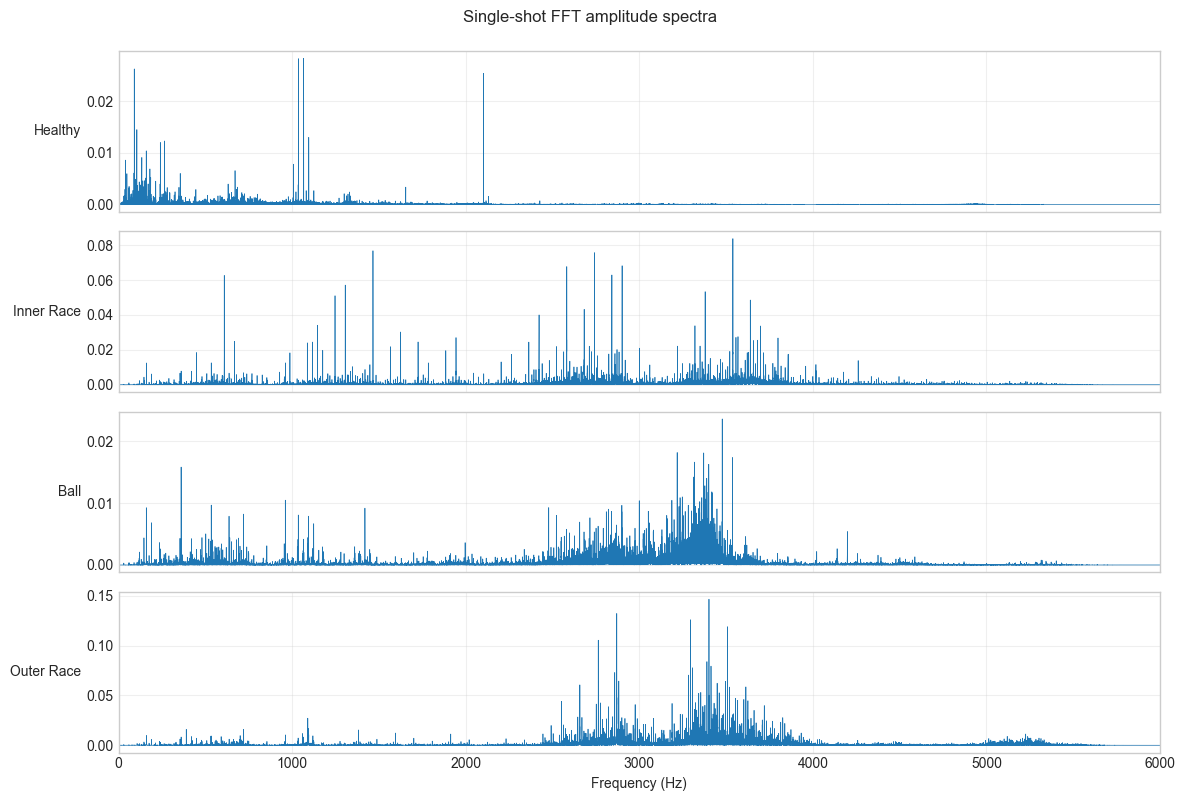

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

for ax, (condition, (freqs, amps)) in zip(axes, ffts.items()):
    ax.plot(freqs, amps, linewidth=0.5)
    ax.set_ylabel(condition, rotation=0, ha='right', va='center', fontsize=10)
    ax.set_xlim(0, 6000)  # plot up to Nyquist
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Frequency (Hz)')
fig.suptitle('Single-shot FFT amplitude spectra', fontsize=12, y=0.995)
fig.tight_layout()
plt.show()

In [8]:
def welch_psd(signal, fs, nperseg=4096):
    """
    Compute Welch's power spectral density estimate.

    Parameters
    ----------
    signal : ndarray
        1D time-series signal
    fs : float
        Sampling frequency in Hz
    nperseg : int
        Segment length in samples. Frequency resolution is fs/nperseg.

    Returns
    -------
    freqs : ndarray
        Frequency axis in Hz
    psd : ndarray
        Power spectral density in (signal units)^2 / Hz
    """
    freqs, psd = welch(
        signal,
        fs=fs,
        nperseg=nperseg,
        noverlap=nperseg // 2,
        window='hann',
    )
    return freqs, psd

In [9]:
psds = {}
for condition, signal in signals.items():
    freqs, psd = welch_psd(signal, fs)
    psds[condition] = (freqs, psd)

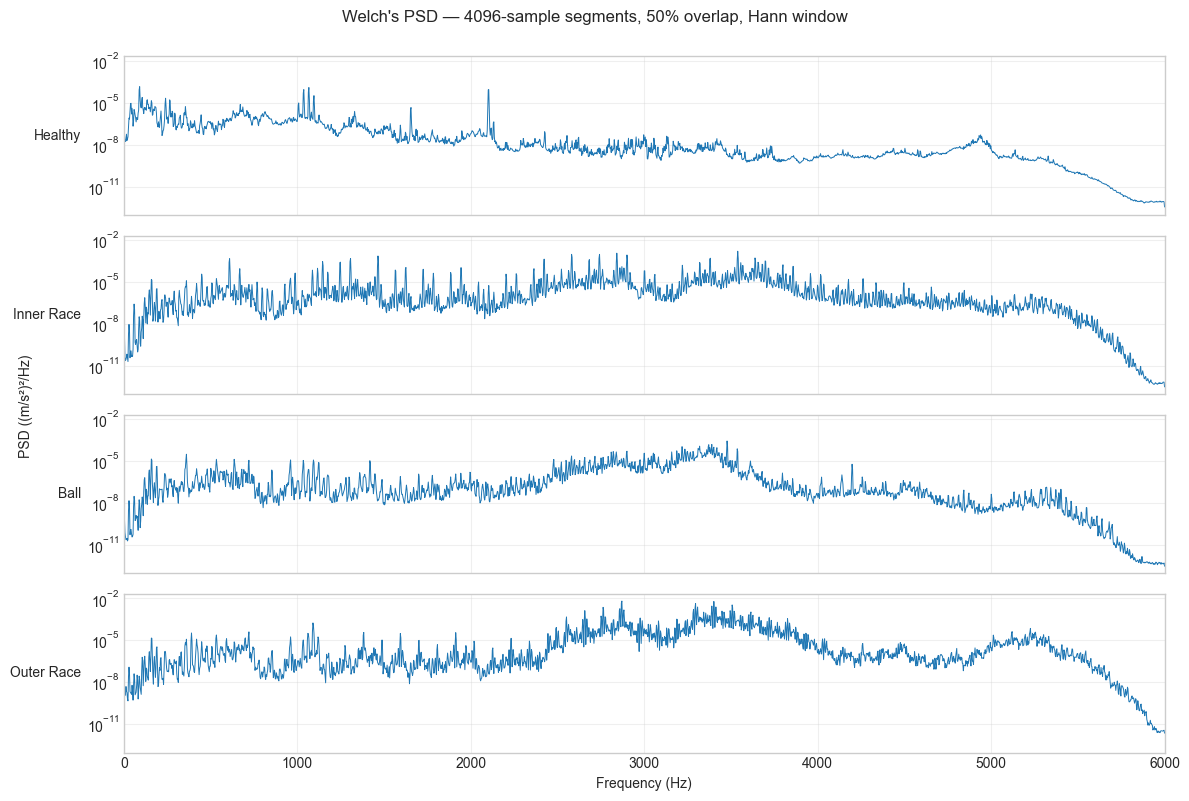

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True, sharey=True)

for ax, (condition, (freqs, psd)) in zip(axes, psds.items()):
    ax.semilogy(freqs, psd, linewidth=0.7)
    ax.set_ylabel(condition, rotation=0, ha='right', va='center', fontsize=10)
    ax.set_xlim(0, 6000)
    ax.grid(True, which='both', alpha=0.3)

axes[-1].set_xlabel('Frequency (Hz)')
fig.text(0.02, 0.5, 'PSD ((m/s²)²/Hz)', rotation=90, va='center')
fig.suptitle("Welch's PSD — 4096-sample segments, 50% overlap, Hann window", fontsize=12, y=0.995)
fig.tight_layout()
plt.show()

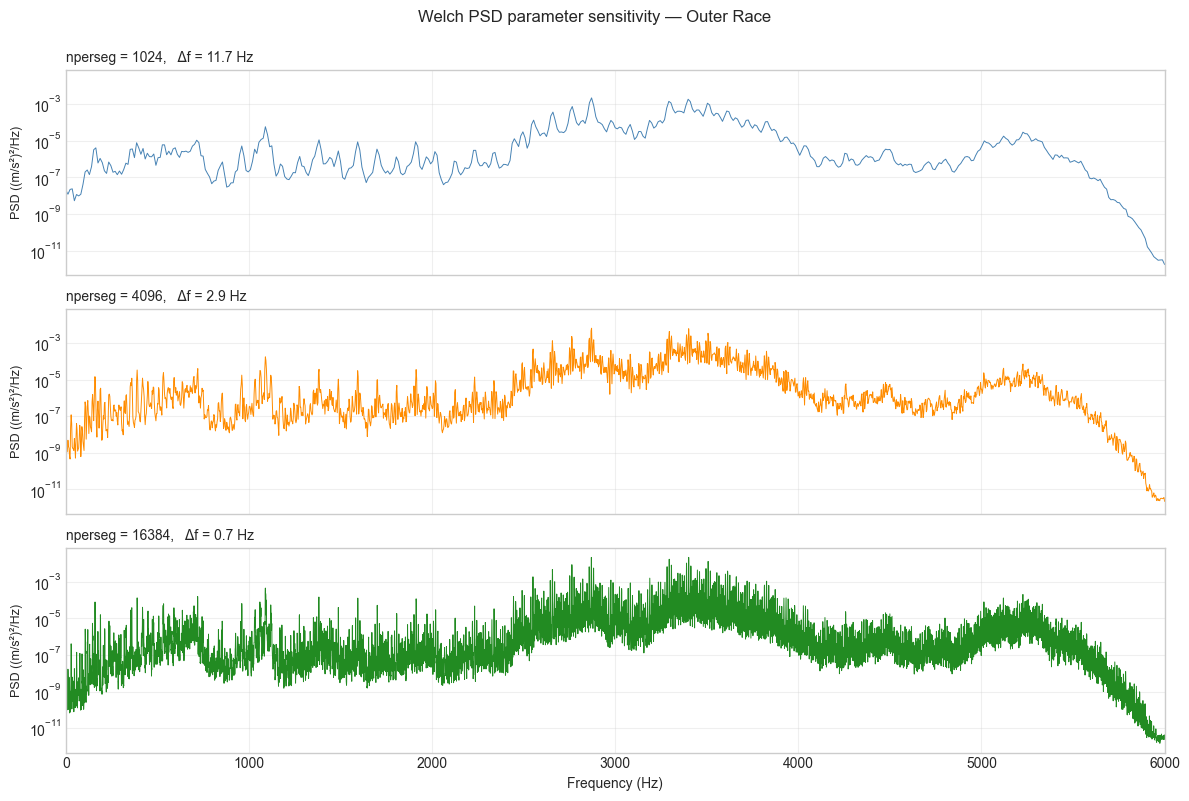

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, sharey=True)

nperseg_values = [1024, 4096, 16384]
colors = ['steelblue', 'darkorange', 'forestgreen']

for ax, L, color in zip(axes, nperseg_values, colors):
    f, P = welch_psd(signals['Outer Race'], fs, nperseg=L)
    ax.semilogy(f, P, linewidth=0.7, color=color)
    ax.set_title(f'nperseg = {L},   Δf = {fs/L:.1f} Hz', fontsize=10, loc='left')
    ax.set_ylabel('PSD ((m/s²)²/Hz)', fontsize=9)
    ax.set_xlim(0, 6000)
    ax.grid(True, which='both', alpha=0.3)

axes[-1].set_xlabel('Frequency (Hz)')
fig.suptitle('Welch PSD parameter sensitivity — Outer Race', fontsize=12, y=0.995)
fig.tight_layout()
fig.savefig('../figures/welch_parameter_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
bearing_6205 = {
    'name': 'SKF 6205-2RS JEM',
    'n_balls': 9,
    'ball_diameter_in': 0.3126,
    'pitch_diameter_in': 1.537,
    'contact_angle_deg': 0.0,
    'source': 'https://engineering.case.edu/bearingdatacenter/bearing-information',
}

The four characteristic bearing fault frequencies are computed from the
bearing geometry and shaft speed:

$$f_r = \frac{\text{RPM}}{60}$$

$$\text{BPFI} = \frac{N_b}{2} f_r \left(1 + \frac{d}{D}\cos\alpha\right)$$

$$\text{BPFO} = \frac{N_b}{2} f_r \left(1 - \frac{d}{D}\cos\alpha\right)$$

$$\text{BSF} = \frac{D}{d} f_r \left(1 - \left(\frac{d}{D}\cos\alpha\right)^2\right)$$

$$\text{FTF} = \frac{f_r}{2} \left(1 - \frac{d}{D}\cos\alpha\right)$$

where $f_r$ is the shaft rotation frequency (Hz), $N_b$ is the number of
rolling elements, $d$ is the ball diameter, $D$ is the pitch diameter,
and $\alpha$ is the contact angle.

The BSF expression here uses the **impact convention** (twice the ball
rotational frequency), which is the diagnostically relevant rate at which
a defect on a rolling element strikes a race. Some references present BSF
as the rotational frequency, which is half this value — the conventions
differ in the literature by a factor of two.

**References**
- CWRU Bearing Data Center, geometry and published coefficients:
  https://engineering.case.edu/bearingdatacenter/bearing-information
- Bearing Fault Frequency Equations:
  https://power-mi.com/content/rolling-element-bearing-components-and-failing-frequencies

In [19]:
def bearing_fault_frequencies(rpm, bearing):
    """
    Compute characteristic bearing fault frequencies.

    Parameters
    ----------
    rpm : float
        Shaft speed in revolutions per minute
    bearing : dict
        Bearing geometry with keys 'n_balls', 'ball_diameter_in',
        'pitch_diameter_in', 'contact_angle_deg'

    Returns
    -------
    dict
        Frequencies in Hz: 'f_shaft', 'BPFI', 'BPFO', 'BSF', 'FTF'
    """
    f_r = rpm / 60.0
    n = bearing['n_balls']
    d = bearing['ball_diameter_in']
    D = bearing['pitch_diameter_in']
    alpha = np.radians(bearing['contact_angle_deg'])

    ratio = (d / D) * np.cos(alpha)

    return {
        'f_shaft': f_r,
        'BPFI': (n / 2) * f_r * (1 + ratio),
        'BPFO': (n / 2) * f_r * (1 - ratio),
        'BSF':  (D / d) * f_r * (1 - ratio**2),
        'FTF':  (f_r / 2) * (1 - ratio),
    }

In [18]:
fault_freqs = bearing_fault_frequencies(1772, bearing_6205)

# Display as a clean table
df_freqs = pd.DataFrame({
    'Frequency (Hz)': fault_freqs,
}).round(2)
df_freqs.index.name = 'Component'
df_freqs

,Frequency (Hz)
Component,
f_shaft,29.53
BPFI,159.93
BPFO,105.87
BSF,139.20
FTF,11.76


In [21]:
cwru_coefficients = {
    'BPFI': 5.4152,
    'BPFO': 3.5848,
    'BSF':  4.7135,
    'FTF':  0.39828,
}

f_r = fault_freqs['f_shaft']
print(f"{'Component  ':<8}{'Computed (Hz)':<18}{'CWRU (Hz)':<14}{'Match':<8}")
for component, coeff in cwru_coefficients.items():
    computed = fault_freqs[component]
    cwru = coeff * f_r
    match = '✓' if abs(computed - cwru) < 0.01 else '✗'
    print(f"{component:<8}{computed:<18.3f}{cwru:<14.3f}{match:<8}")

Component  Computed (Hz)     CWRU (Hz)     Match   
BPFI    159.930           159.929       ✓       
BPFO    105.870           105.871       ✓       
BSF     139.204           139.205       ✓       
FTF     11.763            11.763        ✓       


In [22]:
# Frequencies to overlay on each condition's spectrum
overlay_freqs = {
    'Healthy': {
        'f_shaft': fault_freqs['f_shaft'],
    },
    'Inner Race': {
        'f_shaft': fault_freqs['f_shaft'],
        'BPFI':    fault_freqs['BPFI'],
        '2×BPFI':  2 * fault_freqs['BPFI'],
        '3×BPFI':  3 * fault_freqs['BPFI'],
    },
    'Ball': {
        'f_shaft': fault_freqs['f_shaft'],
        'FTF':     fault_freqs['FTF'],
        'BSF':     fault_freqs['BSF'],
        '2×BSF':   2 * fault_freqs['BSF'],
    },
    'Outer Race': {
        'f_shaft': fault_freqs['f_shaft'],
        'BPFO':    fault_freqs['BPFO'],
        '2×BPFO':  2 * fault_freqs['BPFO'],
        '3×BPFO':  3 * fault_freqs['BPFO'],
        '4×BPFO':  4 * fault_freqs['BPFO'],
    },
}

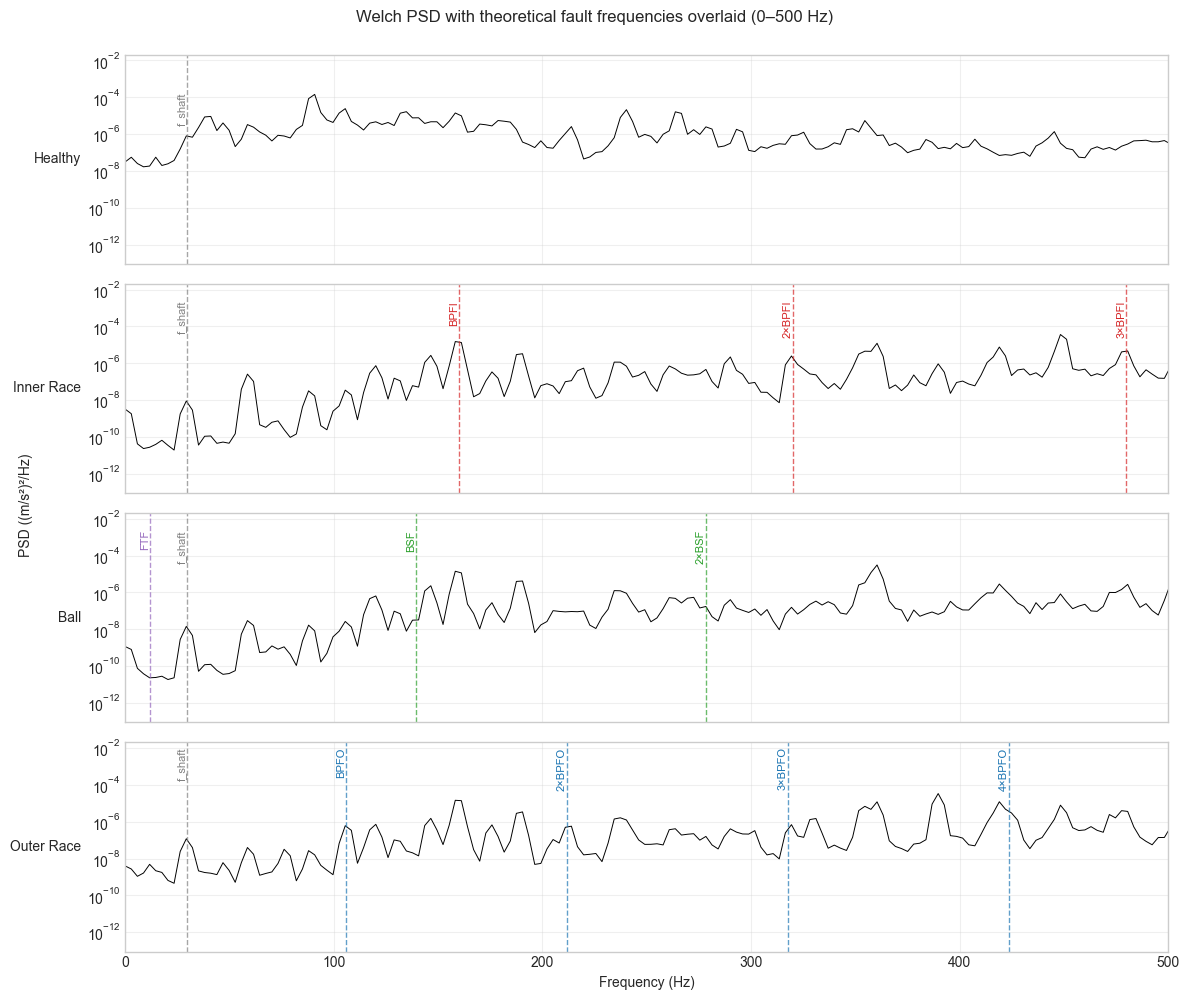

In [24]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True, sharey=True)

# Distinct colours for the different frequency types
freq_colors = {
    'f_shaft': 'gray',
    'FTF':     'tab:purple',
    'BPFI':    'tab:red',
    'BPFO':    'tab:blue',
    'BSF':     'tab:green',
}

for ax, (condition, (freqs, psd)) in zip(axes, psds.items()):
    # Plot the spectrum
    ax.semilogy(freqs, psd, linewidth=0.7, color='black')

    # Overlay vertical lines at the relevant fault frequencies
    for label, f in overlay_freqs[condition].items():
        # Pick colour by the base frequency name (strip the multiplier)
        base = label.split('×')[-1] if '×' in label else label
        color = freq_colors.get(base, 'gray')
        ax.axvline(f, color=color, linestyle='--', linewidth=1.0, alpha=0.7)
        # Label at top of the plot
        ax.text(f, ax.get_ylim()[1] * 0.5, label,
                rotation=90, ha='right', va='top', fontsize=8,
                color=color)

    ax.set_ylabel(condition, rotation=0, ha='right', va='center', fontsize=10)
    ax.set_xlim(0, 500)
    ax.grid(True, which='both', alpha=0.3)

axes[-1].set_xlabel('Frequency (Hz)')
fig.text(0.02, 0.5, 'PSD ((m/s²)²/Hz)', rotation=90, va='center')
fig.suptitle('Welch PSD with theoretical fault frequencies overlaid (0–500 Hz)',
             fontsize=12, y=0.995)
fig.tight_layout()
fig.savefig('../figures/welch_psd_overlay_lowfreq.png', dpi=150, bbox_inches='tight')
plt.show()